# Model and Wrapper

## Model

In [2]:
from torch import nn
from typing import Literal

class MLPClassifier(nn.Module):
    def __init__(self, n_hidden:int, hidden_dim:int, input_dim:int, output_dim:int, activation:Literal['ReLU', 'Tanh'] = 'ReLU'):
        super(MLPClassifier, self).__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)

        if activation == 'ReLU':
            self.activation = nn.ReLU()
        elif activation == 'Tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError(f"Unknown activation function: {activation}")

    def forward(self, input):
        x = self.activation(self.input_layer(input))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)

        return x.squeeze(1) if x.shape[-1] == 1 else x

## Wrapper

In [1]:
import numpy as np
from torch.nn.utils import clip_grad_norm_
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import accuracy_score

class MyWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, model, classes:list | np.ndarray, lr:float=1e-3, epochs:int=50, batch_size:int=None, device:torch.device=None, is_fitted:bool = False):
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device

        self.model = model.to(self.device)
        self.classes = classes
        self.classes_ = classes

        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.is_fitted  = is_fitted


    def fit(self, X: np.ndarray, y: np.ndarray, sample_weight=None) -> float:
        def _train_one_epoch(model, loader, optimizer, criterion, max_norm:float=1.0):
            model.train()
            running_loss = 0.0
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                optimizer.zero_grad()
                loss = criterion(model(X), y)
                running_loss += loss.item()
                loss.backward()
                clip_grad_norm_(model.parameters(), max_norm=max_norm)
                optimizer.step()
            avg_loss = running_loss / len(loader)

            return avg_loss

        self.model.to(self.device)
        optimzer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        if len(self.classes) == 2:
            criterion = nn.BCEWithLogitsLoss()
            y_tensor = torch.Tensor(y).to(self.device)

        else:
            criterion = nn.CrossEntropyLoss()
            y_tensor = torch.Tensor(y).long().to(self.device)

        X_tensor = torch.Tensor(X).to(self.device)

        if sample_weight is not None:
            sampler = WeightedRandomSampler(sample_weight, len(X_tensor), replacement=True)
        else:
            sampler = None

        train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=self.batch_size, sampler=sampler)

        running_loss = 0.0
        for epoch in range(self.epochs):
            running_loss += _train_one_epoch(self.model, train_loader, optimzer, criterion)

        print(f'Avrage Loss {running_loss/self.epochs}')

        self.is_fitted = True
        return self


    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X_tensor = torch.Tensor(X).to(self.device)

        self.model.eval()
        output = self.model(X_tensor)

        if len(self.classes) == 2:
            proba = torch.sigmoid(output).detach().cpu().numpy()
            proba = proba.reshape(-1, 1)
            proba = np.hstack([1 - proba, proba])
        else:
            proba = torch.softmax(output, dim=1).detach().cpu().numpy()


        return proba

    def predict(self, X: np.ndarray) -> np.ndarray:
        proba = self.predict_proba(X)

        if len(self.classes) == 2:
            preds = self.classes[(proba[:, 1] >= 0.5).astype(int)]
        else:
            preds = self.classes[proba.argmax(axis=1)]

        return preds


    def score(self, X, y, sample_weight=None):
        check_is_fitted(self, attributes=["is_fitted"])
        y_pred = self.predict(X)

        return accuracy_score(y, y_pred, sample_weight=sample_weight)


## Report Function

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, classification_report, confusion_matrix
import numpy as np
import warnings

# Suppress all FutureWarnings
warnings.filterwarnings("ignore")


def report(model:MyWrapper, X: np.ndarray, target: np.ndarray, classes: list):
    """
    Generates a classification report, confusion matrix, and ROC curves
    by generating predictions directly from the provided model and features.
    """
    # Generate predictions inside the function
    y_proba = model.predict_proba(X)
    y_pred = model.predict(X)

    fig, ax = plt.subplots(1, 2, figsize=(20, 6))
    ax = ax.flatten()

    # 1. Confusion Matrix
    cf_mtx = confusion_matrix(target, y_pred)
    sns.heatmap(cf_mtx, annot=True, fmt="g", ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xticklabels(classes)
    ax[0].set_yticklabels(classes)

    # 2. Multiclass ROC Curve (One-vs-Rest)
    for idx in range(len(classes)):
        fpr, tpr, thresholds = roc_curve(target == idx, y_proba[:, idx])
        roc_auc = auc(fpr, tpr)
        display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
        display.plot(ax=ax[1])

    ax[1].plot([0, 1], [0, 1], color='white', linestyle='--')
    ax[1].set_title('Multiclass ROC Curve (One-vs-Rest)')

    plt.legend(classes)
    plt.show()

    # 3. Text Classification Report
    clf_r = classification_report(target, y_pred, target_names=[str(c) for c in classes])
    print(clf_r)

# Data

In [5]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os


path = os.path.join('Data', 'test.csv')
data = pd.read_csv(path)

target_name = 'NObeyesdad'
X, y = data.drop([target_name], axis=1), data[target_name]


print(f'test set: {len(y)}')

test set: 4152


# Model and Classifcation report


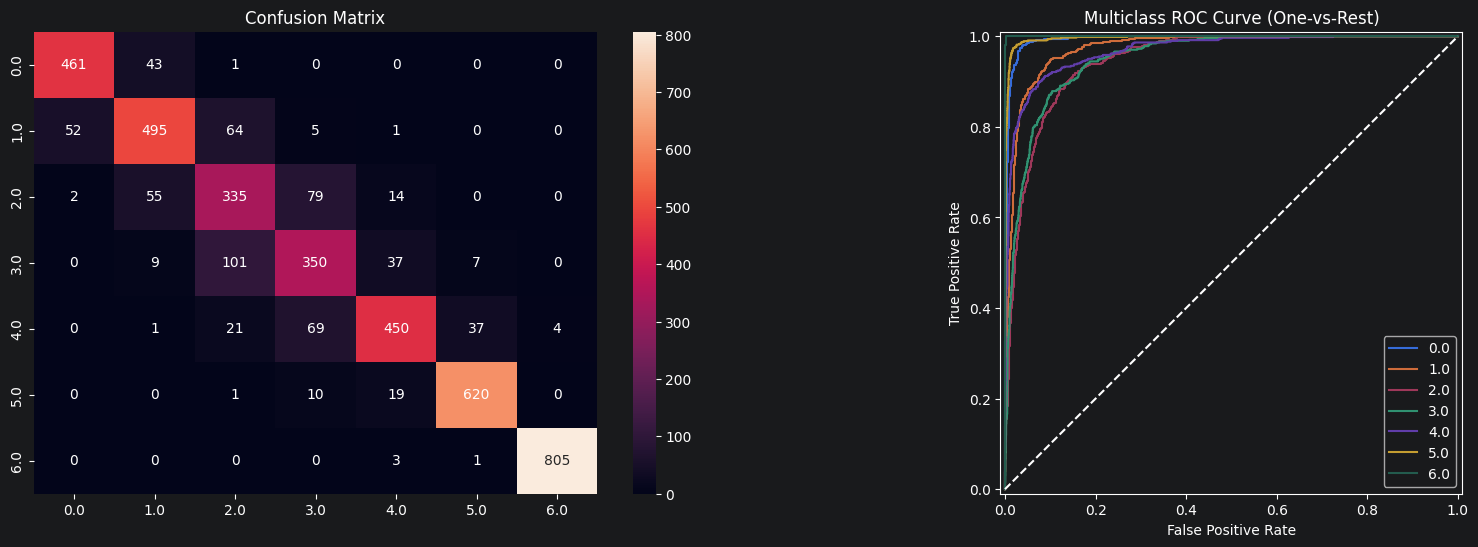

              precision    recall  f1-score   support

         0.0       0.90      0.91      0.90       505
         1.0       0.82      0.80      0.81       617
         2.0       0.64      0.69      0.66       485
         3.0       0.68      0.69      0.69       504
         4.0       0.86      0.77      0.81       582
         5.0       0.93      0.95      0.94       650
         6.0       1.00      1.00      1.00       809

    accuracy                           0.85      4152
   macro avg       0.83      0.83      0.83      4152
weighted avg       0.85      0.85      0.85      4152



In [7]:
model_path = os.path.join('Models', 'NotCalibrated', 'last.ckpt')
checkpoint = torch.load(model_path, map_location=lambda storage, loc: storage)

X_np = X.to_numpy()
y_np = y.to_numpy()

model_config = checkpoint["hyper_parameters"]
model_config.pop('lr')

raw_state_dict = checkpoint['state_dict']
clean_state_dict = {k.replace('model.', ''): v for k, v in raw_state_dict.items()}

model = MLPClassifier(**model_config)
model.load_state_dict(clean_state_dict)

sorted_classes = np.sort(y.unique())
wrappedModel = MyWrapper(model, classes=sorted_classes, is_fitted=True, device=torch.device('cpu'))
report(wrappedModel, X_np, y_np, classes=sorted_classes)

# XAI - What influences model decision?

## Feature Permutation

In [10]:
from sklearn.inspection import permutation_importance
print(f"\n--- Permutation Importance ---")
significant_features = []

for i in range(X.shape[1]):
    result = permutation_importance(wrappedModel, X_np, y_np, n_repeats=100, random_state=0, scoring='accuracy')
    mean = result.importances_mean[i]
    std = result.importances_std[i]

    # Wyznaczenie 95% przedziału ufności dla średniej
    margin_of_error = 1.96 * (std / np.sqrt(100))
    ci_lower = mean - margin_of_error
    ci_upper = mean + margin_of_error

    if ci_upper < 0 or ci_lower > 0:
        significant_features.append((i, mean, ci_lower, ci_upper))
        print(f"Cecha {i}: Mean={mean:.4f}, CI=[{ci_lower:.4f}, {ci_upper:.4f}]")


--- Permutation Importance ---
Cecha 0: Mean=0.0071, CI=[0.0068, 0.0075]
Cecha 1: Mean=0.0279, CI=[0.0273, 0.0285]
Cecha 2: Mean=0.0255, CI=[0.0249, 0.0260]
Cecha 3: Mean=0.0086, CI=[0.0080, 0.0091]
Cecha 4: Mean=0.0049, CI=[0.0045, 0.0052]
Cecha 5: Mean=0.0904, CI=[0.0895, 0.0913]
Cecha 6: Mean=0.5781, CI=[0.5767, 0.5795]
Cecha 7: Mean=0.1732, CI=[0.1722, 0.1742]
Cecha 8: Mean=0.0079, CI=[0.0075, 0.0082]
Cecha 9: Mean=0.0264, CI=[0.0259, 0.0269]


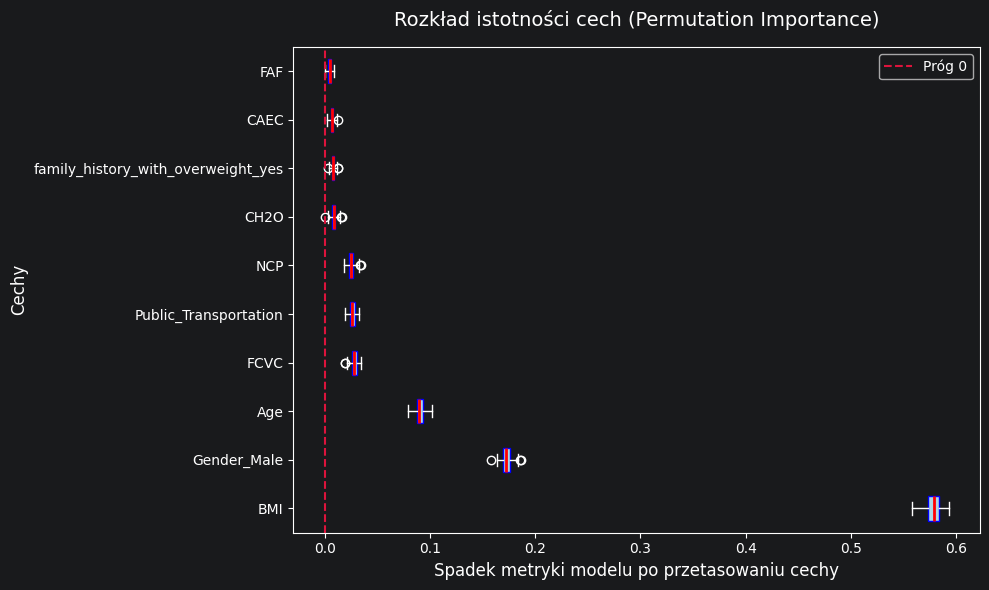

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

feature_names = (
    X.columns
    if hasattr(X, "columns")
    else [f"Cecha {i}" for i in range(X.shape[1])]
)


sorted_importances_idx = result.importances_mean.argsort()[::-1]
sorted_feature_names = [feature_names[i] for i in sorted_importances_idx]
sorted_importances = result.importances[sorted_importances_idx]

plt.figure(figsize=(10, 6))

plt.boxplot(
    sorted_importances.T,
    vert=False,
    labels=sorted_feature_names,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red", linewidth=2),
)

plt.axvline(x=0, color="crimson", linestyle="--", linewidth=1.5, label="Próg 0")

plt.title("Rozkład istotności cech (Permutation Importance)", fontsize=14, pad=15)
plt.xlabel("Spadek metryki modelu po przetasowaniu cechy", fontsize=12)
plt.ylabel("Cechy", fontsize=12)
plt.legend(loc="upper right")
plt.tight_layout()

plt.show()